In [ ]:
Part 1

In [2]:
from pydataset import data


In [3]:
import pandas as pd

In [4]:
! pip install pydataset

In [10]:
from pydataset import data
df = data('mtcars')

In [12]:
#2. Display the first 5 rows.

mtcars.head(5)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
#3. Check:
#○ shape of the dataset
#○ column names
#○ data types
#○ summary statistics



In [13]:
mtcars.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [14]:
mtcars.dtypes


mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [15]:
mtcars.sum()

mpg      642.900
cyl      198.000
disp    7383.100
hp      4694.000
drat     115.090
wt       102.952
qsec     571.160
vs        14.000
am        13.000
gear     118.000
carb      90.000
dtype: float64

In [17]:
#4. Check whether there are any missing values.
mtcars.values.any()

np.True_

In [ ]:
Part 2: Basic Data Analysis

In [ ]:
#5. Find
○ average mileage (mpg)


In [21]:
mtcars.mean()

mpg      20.090625
cyl       6.187500
disp    230.721875
hp      146.687500
drat      3.596563
wt        3.217250
qsec     17.848750
vs        0.437500
am        0.406250
gear      3.687500
carb      2.812500
dtype: float64

In [30]:
mean_mpg=mtcars['mpg'].mean()
print(mean_mpg)

20.090625000000003


In [31]:
# maximum horsepower (hp)
max_hp=mtcars['hp'].max()
print(max_hp)

335


In [37]:
#○ minimum and maximum weight (wt)
mean_wt=mtcars['wt'].mean().round(2)
print(mean_wt)

3.22


In [34]:
max_wt=mtcars['wt'].max()
print(max_wt)

5.424


In [ ]:
#6. Count how many cars have:
○ 4 cylinders
○ 6 cylinders
○ 8 cylinders

In [41]:
mtcars.count()


mpg     32
cyl     32
disp    32
hp      32
drat    32
wt      32
qsec    32
vs      32
am      32
gear    32
carb    32
dtype: int64

In [42]:
mtcars['cyl'].value_counts()

cyl
8    14
4    11
6     7
Name: count, dtype: int64

In [ ]:
#7. Find the average mileage for each cylinder category using groupby().

In [46]:
mean_mpg=mtcars.groupby('cyl').mean('mpg').round(2)
print(mean_mpg)

       mpg    disp      hp  drat    wt   qsec    vs    am  gear  carb
cyl                                                                  
4    26.66  105.14   82.64  4.07  2.29  19.14  0.91  0.73  4.09  1.55
6    19.74  183.31  122.29  3.59  3.12  17.98  0.57  0.43  3.86  3.43
8    15.10  353.10  209.21  3.23  4.00  16.77  0.00  0.14  3.29  3.50


In [50]:
mean_mpg=mtcars.groupby('cyl')['mpg'].mean().round(2)
print(mean_mpg)

cyl
4    26.66
6    19.74
8    15.10
Name: mpg, dtype: float64


In [ ]:
#Part 3: Intermediate Analysis
#8. Compare average mileage by:
# transmission type (am)

In [51]:
mtcars.groupby('am')['mpg'].mean()

am
0    17.147368
1    24.392308
Name: mpg, dtype: float64

In [52]:
# number of gears (gear)
mtcars.groupby('gear')['mpg'].mean()

gear
3    16.106667
4    24.533333
5    21.380000
Name: mpg, dtype: float64

In [53]:
mtcars.groupby(['am', 'gear'])['mpg'].mean()

am  gear
0   3       16.106667
    4       21.050000
1   4       26.275000
    5       21.380000
Name: mpg, dtype: float64

In [54]:
#9. Create a pivot table showing average mpg by cyl and am.
mtcars.pivot_table(values='mpg', index='cyl', columns='am', aggfunc='mean')

am,0,1
cyl,,
4,22.900,28.075000
6,19.125,20.566667
8,15.050,15.400000


In [57]:
#10. Create a new column:
#● efficiency where cars with mpg >20 are labeled 'High' and others 'Low'.

In [58]:
mtcars[['mpg', 'efficiency']].head()

,mpg,efficiency
Mazda RX4,21.0,High
Mazda RX4 Wag,21.0,High
Datsun 710,22.8,High
Hornet 4 Drive,21.4,High
Hornet Sportabout,18.7,Low


In [65]:
#11. Use map() to convert:
#● am: 0 = Automatic, 1 = Manual
#● vs: 0 = V-shaped, 1 = Straight
mtcars['am'] = mtcars['am'].map({0: 'Automatic', 1: 'Manual'})

In [66]:
mtcars['transmission'] = mtcars['am'].map({0: 'Automatic', 1: 'Manual'})
mtcars['engine'] = mtcars['vs'].map({0: 'V-shaped', 1: 'Straight'})

In [67]:
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency,transmission,engine
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,NaN,NaN,4,4,High,NaN,NaN
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,NaN,NaN,4,4,High,NaN,NaN
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,NaN,NaN,4,1,High,NaN,NaN
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,NaN,NaN,3,1,High,NaN,NaN
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,NaN,NaN,3,2,Low,NaN,NaN


In [68]:
#Part 4: Data Visualization
#12. Create at least 3 charts, such as:
#13. Write 1-2 observations below each chart.
#● bar chart of average mpg by cylinders
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
#The cars with less cylinders have higher average Mpg than cylinder 8 and 6.

In [69]:
avg_mpg = mtcars.groupby('cyl')['mpg'].mean()

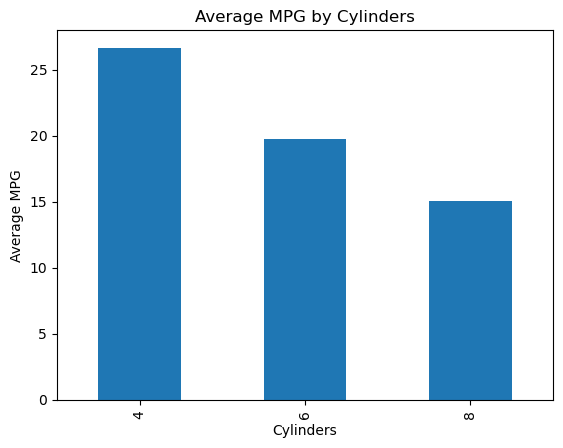

In [70]:
avg_mpg.plot(kind='bar')
plt.title('Average MPG by Cylinders')
plt.xlabel('Cylinders')
plt.ylabel('Average MPG')
plt.show()

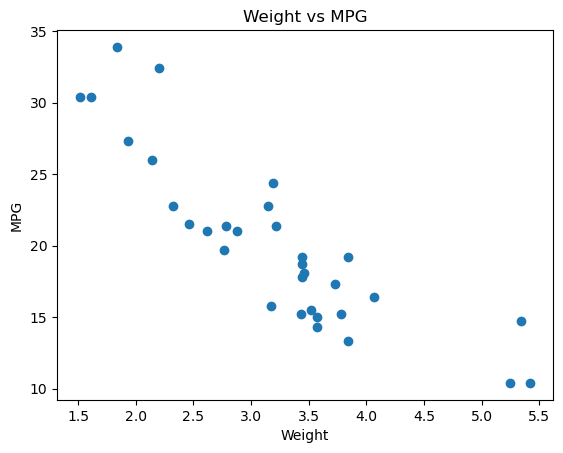

In [71]:
#● scatter plot of wt vs mpg
plt.scatter(mtcars['wt'], mtcars['mpg'])
plt.title('Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

In [ ]:
#The scatter plot showa the weight of the cars increases, the mileage decrease.

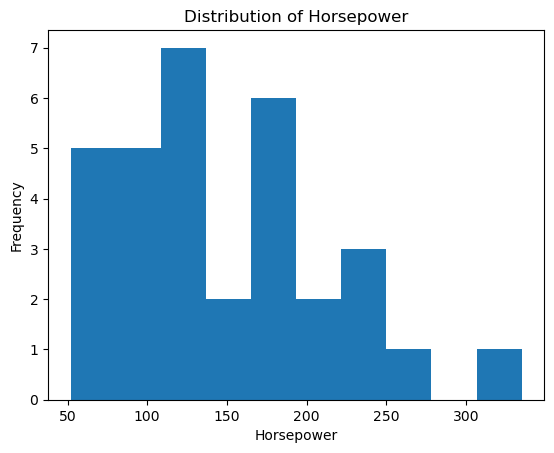

In [72]:
#● histogram of horsepower
plt.hist(mtcars['hp'])
plt.title('Distribution of Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#The cars shows higher horsepower falls in below 1 and 2 frequency.

In [ ]:
#● boxplot of mpg by transmission: NEED HELP TO LEARN IT.

In [ ]:
#Part 5: Insights and Conclusion
#14. Write at least 5 insights from the dataset.
# Manual cars show a wider spread of 'mpg' values compared to automatic cars.
#Lighter cars have better fuel effiency.
#Cars with higher horsepower end up indicates low mpg.
# 4 gear cars perform best on average than 5 gear cars.
# cars with low fuel efficiency fall under automatic transmission.

In [ ]:
#15. In a nutshell, the analysis shows that fuel  efficiency varies significantly across different vehicle characteristics. Cars with smaller engines and lower weight consistently achieve better mileage, while high-performance vehicles tend to be less economical.
#Transmission type also influences efficiency, with manual cars generally offering better MPG. Although factors like gears and engine shape contribute to performance, their effects are less pronounced compared to weight and engine size. Overall, the dataset highlights 
#a clear balance between power and efficiency, where improvements in one often lead to compromises in the other.